# 05. Детекция плагиата (chunk-to-chunk)

**Логика:**
Для каждой пары документов (A, B):
1. Считаем матрицу `sim[i,j] = emb_A[i] · emb_B[j]`
2. Для каждого чанка A находим лучший матч в B
3. Overlap score = доля чанков с `max_sim > MATCH_THRESHOLD`
4. Суспициозность = `max(overlap_A, overlap_B)`

**Отчёт:**
- Топ-N подозрительных пар
- Совпадающие фрагменты (token ranges + cos sim)

In [ ]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

OUT_DIR = Path('artifacts')

MATCH_THRESHOLD    = 0.90
SUSPECT_OVERLAP    = 0.20
MIN_CHUNKS         = 8
MIN_MATCHED_COUNT  = 3
SKIP_INTRO_CHUNKS  = 2
TOP_N_PAIRS        = 30
TOP_K_MATCHES      = 5

In [10]:
embeddings  = np.load(OUT_DIR / 'embeddings.npy')
chunks_meta = pd.read_pickle(OUT_DIR / 'chunks_meta.pkl')
df          = pd.read_pickle(OUT_DIR / 'df_corpus_ready.pkl').reset_index(drop=True)
with open(OUT_DIR / 'embeddings_config.pkl', 'rb') as f:
    cfg = pickle.load(f)

print(f'Документов          : {len(df)}')
print(f'Чанков              : {len(chunks_meta)}')
print(f'Размерность         : {embeddings.shape}')
print(f'Конфиг эмбеддингов  : {cfg}')

# sanity: чанки нормализованы
norms = np.linalg.norm(embeddings, axis=1)
assert np.allclose(norms, 1.0, atol=1e-3), f'Эмбеддинги не нормализованы: norm.mean={norms.mean()}'

Документов          : 194
Чанков              : 4986
Размерность         : (4986, 768)
Конфиг эмбеддингов  : {'model_id': 'ibm-granite/granite-embedding-311m-multilingual-r2', 'max_len': 512, 'overlap': 64, 'text_col': 'clean_text', 'hidden_dim': 768, 'n_docs': 194, 'n_chunks': 4986}


In [11]:
print('Считаем полную cos-sim матрицу чанков...')
S = embeddings @ embeddings.T   # (N, N) float32
print(f'Матрица S: shape={S.shape}, mem={S.nbytes / 1e6:.1f} MB')

# Обнуляем диагональ (чанк сам с собой)
np.fill_diagonal(S, 0.0)

# Маска «чанк в том же документе» — зануляем
doc_idx = chunks_meta['doc_idx'].to_numpy()
same_doc_mask = doc_idx[:, None] == doc_idx[None, :]
S[same_doc_mask] = 0.0

print(f'\nРаспределение cos sim (межу разными документами):')
offdiag = S[~same_doc_mask]
print(f'  min    : {offdiag.min():.3f}')
print(f'  median : {np.median(offdiag):.3f}')
print(f'  mean   : {offdiag.mean():.3f}')
print(f'  p95    : {np.percentile(offdiag, 95):.3f}')
print(f'  p99    : {np.percentile(offdiag, 99):.3f}')
print(f'  max    : {offdiag.max():.3f}')

Считаем полную cos-sim матрицу чанков...
Матрица S: shape=(4986, 4986), mem=99.4 MB

Распределение cos sim (межу разными документами):
  min    : 0.057
  median : 0.511
  mean   : 0.517
  p95    : 0.689
  p99    : 0.757
  max    : 0.993


In [ ]:
def body_chunk_indices(doc_id):
    idx = chunks_meta.index[(chunks_meta['doc_idx'] == doc_id) &
                            (chunks_meta['chunk_idx'] >= SKIP_INTRO_CHUNKS)].to_numpy()
    return idx

doc_to_chunks = {d: body_chunk_indices(d) for d in df.index}

chunk_counts = pd.Series({d: len(v) for d, v in doc_to_chunks.items()})
short_docs   = chunk_counts[chunk_counts < MIN_CHUNKS].index.tolist()
print(f'Документов всего              : {len(df)}')
print(f'Отфильтровано коротких (<{MIN_CHUNKS} чанков после пропуска intro): {len(short_docs)}')
print(f'В анализе                    : {len(df) - len(short_docs)}')

n_docs = len(df)
pair_records = []

for a in tqdm(range(n_docs), desc='Pairs'):
    idx_a = doc_to_chunks[a]
    if len(idx_a) < MIN_CHUNKS:
        continue
    for b in range(a + 1, n_docs):
        idx_b = doc_to_chunks[b]
        if len(idx_b) < MIN_CHUNKS:
            continue
        sub = S[np.ix_(idx_a, idx_b)]
        best_a = sub.max(axis=1)
        best_b = sub.max(axis=0)
        matched_a = int((best_a > MATCH_THRESHOLD).sum())
        matched_b = int((best_b > MATCH_THRESHOLD).sum())
        overlap_a = matched_a / len(idx_a)
        overlap_b = matched_b / len(idx_b)
        max_sim   = float(sub.max())
        mean_top5 = float(np.sort(sub, axis=None)[-5:].mean())

        if max(matched_a, matched_b) < MIN_MATCHED_COUNT:
            continue

        pair_records.append({
            'doc_a'      : a,
            'doc_b'      : b,
            'n_chunks_a' : len(idx_a),
            'n_chunks_b' : len(idx_b),
            'matched_a'  : matched_a,
            'matched_b'  : matched_b,
            'overlap_a'  : overlap_a,
            'overlap_b'  : overlap_b,
            'score'      : max(overlap_a, overlap_b),
            'max_sim'    : max_sim,
            'mean_top5'  : mean_top5,
        })

pairs_df = pd.DataFrame(pair_records)
print(f'\nПар (после фильтров)        : {len(pairs_df)}')
print(f'Суспициозных (score >= {SUSPECT_OVERLAP}): {(pairs_df["score"] >= SUSPECT_OVERLAP).sum() if len(pairs_df) else 0}')

Документов всего              : 194
Отфильтровано коротких (<8 чанков после пропуска intro): 22
В анализе                    : 172


Pairs:   0%|          | 0/194 [00:00<?, ?it/s]


Пар (после фильтров)        : 43
Суспициозных (score >= 0.2): 6


In [13]:
pairs_df_sorted = pairs_df.sort_values(['score', 'matched_a', 'matched_b'], ascending=False).reset_index(drop=True)

top = pairs_df_sorted.head(TOP_N_PAIRS).copy()
top['filename_a'] = top['doc_a'].map(df['filename']).str.slice(0, 55)
top['filename_b'] = top['doc_b'].map(df['filename']).str.slice(0, 55)
top['year_a']     = top['doc_a'].map(df['year'])
top['year_b']     = top['doc_b'].map(df['year'])
top['m_a/n_a']    = top.apply(lambda r: f"{r['matched_a']}/{r['n_chunks_a']}", axis=1)
top['m_b/n_b']    = top.apply(lambda r: f"{r['matched_b']}/{r['n_chunks_b']}", axis=1)

show_cols = ['filename_a', 'year_a', 'filename_b', 'year_b', 'm_a/n_a', 'm_b/n_b', 'max_sim', 'score']
pd.set_option('display.max_colwidth', 60)
print(f'=== TOP-{TOP_N_PAIRS} подозрительных пар ===')
print(f'(m/n = совпавших чанков / всего чанков документа после пропуска intro)\n')
print(top[show_cols].to_string(index=False))

=== TOP-30 подозрительных пар ===
(m/n = совпавших чанков / всего чанков документа после пропуска intro)

                                             filename_a year_a                                              filename_b year_b m_a/n_a m_b/n_b  max_sim    score
                2020 БАК Мукашева Дамира Бекзатовна.pdf   2023                 2020 БАК Мұқанова Меруерт Айдынқызы.pdf   2023   11/12   11/12 0.983090 0.916667
Мауленбай С.С. Жоғарғы оқу орындарындағы тіркеуші кеңсе   2019                         2021_БАК_Нагашыбайулы Олжас.pdf   2021   10/29   12/33 0.943682 0.363636
                2021_БАК_Тасыбеков Димаш Жумаханұлы.pdf   2021                  2020 БАК Закір Кенесары Тәжібайұлы.pdf   2023    7/20    6/21 0.965304 0.350000
                        2021_БАК_Нагашыбайулы Олжас.pdf   2021                    2021_БАК_Нургазы Азамат Рахатулы.pdf   2021   11/33    6/26 0.942803 0.333333
                                    2022_БАК_Максат.pdf   2022               2022_БАК_Рахимкул

In [ ]:
def describe_pair(a: int, b: int, k: int = TOP_K_MATCHES):
    idx_a = doc_to_chunks[a]
    idx_b = doc_to_chunks[b]
    sub   = S[np.ix_(idx_a, idx_b)]

    flat  = sub.flatten()
    top_k = np.argpartition(flat, -k)[-k:]
    top_k = top_k[np.argsort(flat[top_k])[::-1]]
    ij    = [(int(idx // sub.shape[1]), int(idx % sub.shape[1])) for idx in top_k]

    print(f'\n{"=" * 90}')
    print(f'A: {df.loc[a, "filename"]}  ({df.loc[a, "year"]})')
    print(f'B: {df.loc[b, "filename"]}  ({df.loc[b, "year"]})')
    print(f'Overlap A→B: {(sub.max(axis=1) > MATCH_THRESHOLD).mean():.1%},  B→A: {(sub.max(axis=0) > MATCH_THRESHOLD).mean():.1%}')
    print(f'Max sim    : {sub.max():.3f}')
    print(f'\nТоп-{k} совпадающих чанков:')
    for ci, cj in ij:
        meta_a = chunks_meta.iloc[idx_a[ci]]
        meta_b = chunks_meta.iloc[idx_b[cj]]
        sim    = sub[ci, cj]
        print(f'  sim={sim:.3f}  A[{meta_a["chunk_idx"]:3d}, токены {meta_a["token_start"]:5d}-{meta_a["token_end"]:5d}]  ↔  B[{meta_b["chunk_idx"]:3d}, токены {meta_b["token_start"]:5d}-{meta_b["token_end"]:5d}]')

for _, row in pairs_df_sorted.head(10).iterrows():
    if row['score'] < SUSPECT_OVERLAP:
        break
    describe_pair(int(row['doc_a']), int(row['doc_b']))


A: 2020 БАК Мукашева Дамира Бекзатовна.pdf  (2023)
B: 2020 БАК Мұқанова Меруерт Айдынқызы.pdf  (2023)
Overlap A→B: 91.7%,  B→A: 91.7%
Max sim    : 0.983

Топ-5 совпадающих чанков:
  sim=0.983  A[  4, токены  1792- 2302]  ↔  B[  4, токены  1792- 2302]
  sim=0.968  A[  2, токены   896- 1406]  ↔  B[  2, токены   896- 1406]
  sim=0.968  A[  7, токены  3136- 3646]  ↔  B[  7, токены  3136- 3646]
  sim=0.967  A[  6, токены  2688- 3198]  ↔  B[  6, токены  2688- 3198]
  sim=0.963  A[  3, токены  1344- 1854]  ↔  B[  3, токены  1344- 1854]

A: Мауленбай С.С. Жоғарғы оқу орындарындағы тіркеуші кеңсеге арналған ақылды чат бот 2019ж.pdf  (2019)
B: 2021_БАК_Нагашыбайулы Олжас.pdf  (2021)
Overlap A→B: 34.5%,  B→A: 36.4%
Max sim    : 0.944

Топ-5 совпадающих чанков:
  sim=0.944  A[ 12, токены  5376- 5886]  ↔  B[ 16, токены  7168- 7678]
  sim=0.940  A[ 11, токены  4928- 5438]  ↔  B[ 15, токены  6720- 7230]
  sim=0.928  A[ 29, токены 12992-13502]  ↔  B[  5, токены  2240- 2750]
  sim=0.926  A[  6, токены

In [ ]:
report = pairs_df_sorted[pairs_df_sorted['score'] >= SUSPECT_OVERLAP].copy()
report['filename_a'] = report['doc_a'].map(df['filename'])
report['filename_b'] = report['doc_b'].map(df['filename'])
report['year_a']     = report['doc_a'].map(df['year'])
report['year_b']     = report['doc_b'].map(df['year'])
report = report[['filename_a', 'year_a', 'filename_b', 'year_b',
                 'n_chunks_a', 'n_chunks_b', 'matched_a', 'matched_b',
                 'overlap_a', 'overlap_b', 'score', 'max_sim', 'mean_top5',
                 'doc_a', 'doc_b']]

report.to_csv(OUT_DIR / 'plagiarism_report.csv', index=False)
pairs_df_sorted.to_pickle(OUT_DIR / 'all_pairs_scores.pkl')

print(f'Сохранено:')
print(f'  plagiarism_report.csv : {len(report)} суспициозных пар (score >= {SUSPECT_OVERLAP})')
print(f'  all_pairs_scores.pkl  : {len(pairs_df_sorted)} всех пар')
print(f'\nПараметры: MATCH_THRESHOLD={MATCH_THRESHOLD}, MIN_CHUNKS={MIN_CHUNKS}, '
      f'MIN_MATCHED_COUNT={MIN_MATCHED_COUNT}, SKIP_INTRO_CHUNKS={SKIP_INTRO_CHUNKS}')

Сохранено:
  plagiarism_report.csv : 6 суспициозных пар (score >= 0.2)
  all_pairs_scores.pkl  : 43 всех пар

Параметры: MATCH_THRESHOLD=0.9, MIN_CHUNKS=8, MIN_MATCHED_COUNT=3, SKIP_INTRO_CHUNKS=2


## 7. Визуализация распределения score

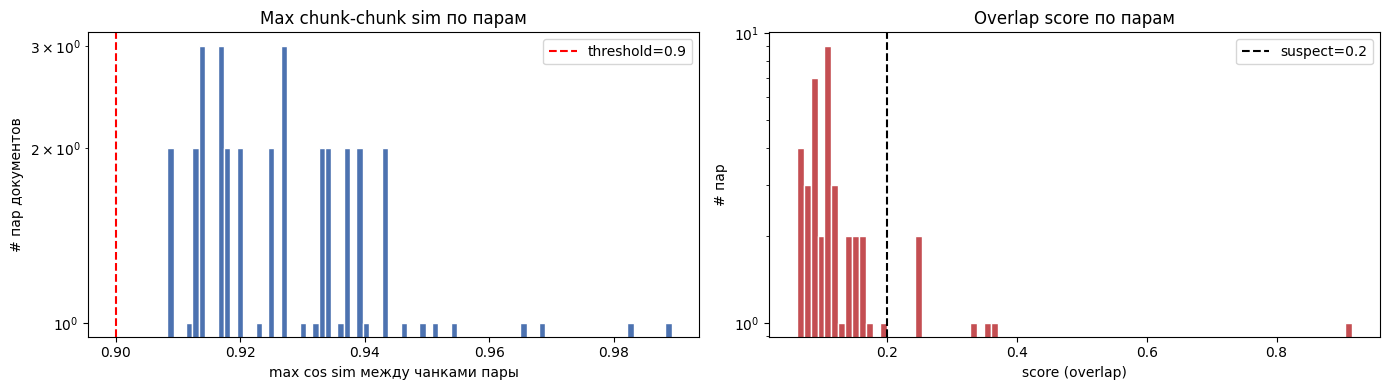

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(pairs_df['max_sim'], bins=80, color='#4c72b0', edgecolor='white')
axes[0].axvline(MATCH_THRESHOLD, color='red', ls='--', label=f'threshold={MATCH_THRESHOLD}')
axes[0].set_xlabel('max cos sim между чанками пары')
axes[0].set_ylabel('# пар документов')
axes[0].set_yscale('log')
axes[0].set_title('Max chunk-chunk sim по парам')
axes[0].legend()

axes[1].hist(pairs_df['score'], bins=80, color='#c44e52', edgecolor='white')
axes[1].axvline(SUSPECT_OVERLAP, color='black', ls='--', label=f'suspect={SUSPECT_OVERLAP}')
axes[1].set_xlabel('score (overlap)')
axes[1].set_ylabel('# пар')
axes[1].set_yscale('log')
axes[1].set_title('Overlap score по парам')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'plagiarism_distributions.png', dpi=120)
plt.show()